# TASK 02

In [14]:
#Step 1: Import Required Libraries

In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.datasets import fetch_california_housing 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

#These libraries handle data manipulation, model training, evaluation, and visualization.

In [16]:
#Step 2:Load the Dataset


In [17]:
#python
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
df.head()


#At this stage, review column names,data types , and the target variable

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [18]:
#Step 3:Separate Features and Target Variable


In [20]:
#python 

x = df.drop("HousePrice",axis=1)
y = df["HousePrice"]

#Machine Learning models require input features (x) and an output variable(y) to be handled separately

In [21]:
#Step 4: Feature Scaling (Critical Step)


In [25]:
#Features in the dataset exist on different numeric ranges without scaling.
#1. some feature dominate others
#2. Model performance becomes unstable

#python
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#After scaling all feature have a common scake,improving learning stability and performance


In [26]:
#Step 5: Train-Test Split

In [ ]:
#python
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

#This ensures the model is evaluted using unseen data rather than memorized values.

In [28]:
#Step 6: Train Multiple Models

In [29]:
#instead of relying on a single algorithm, you will train and evaluate multiple models.
#python

models = {
    "Linear Regression" : LinearRegression(),
    "Ridge Regression" : Ridge(alpha=1.0),
    "Decision Tree" : DecisionTreeRegressor(max_depth=5)
}

#model rationale:
#1. Linear Regression serves as a baseline
#2. Ridge Regression helps reduce overfitting
#3.Decision Tree capture non-linear realationship


In [ ]:
#Step 7:Model Evaluation and Comparison

In [31]:
#python
results = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)

    rmse = np.sqrt(mean_squared_error(y_test,predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE" : rmse,
        "R2 Score" : r2
    }

    results_df = pd.DataFrame(results).T
    results_df

    #interpretation:
    #1. Lower RMSE indicates better prediction accuracy
    #2. Higher R^2 score indicates better explanatory power



In [32]:
#Step 8 : Visual Performance Validation


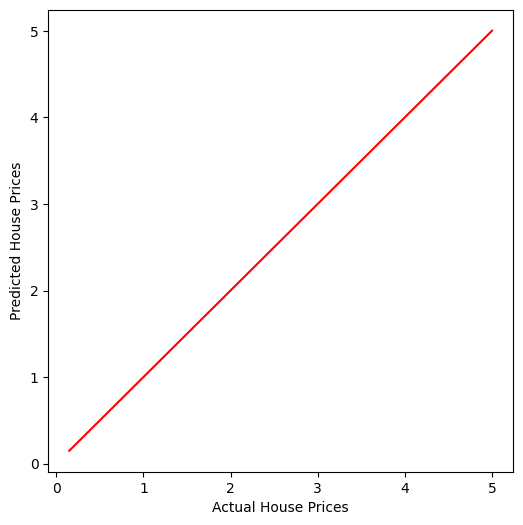

In [34]:
#python

best_model = LinearRegression()
best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)


plt.figure(figsize=(6,6))
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], color="red")
plt.show()

# A closer alignmant of points to the reference line indicates better predictive performance

